In [13]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

import itertools
import seaborn as sns

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
from literal_listener import StatelessLiteralListener
from literal_speaker import LiteralSpeaker
from pragmatic_listener import PragmaticListener
from learner import LearnerAgent

from configuration import TRUE_REWARDS

from visualizations import visualize_pragmatic_beliefs, plot_point_estimate

In [15]:
import torch

# 1. Check if CUDA (NVIDIA GPU support) is available
cuda_available = torch.cuda.is_available()
print(print(f"Is GPU available? {cuda_available}"))

# 2. Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 3. Force your model/tensors to the GPU
# Example tensor:
x = torch.rand(3, 3).to(device) 

# Example model:
# model = MyNeuralNet().to(device)

Is GPU available? True
None
Using device: cuda


# Cache Pragmatic Results

In [16]:
import json
import time

human_utterances = json.load(open("data/Linear_risk.json"))

## Pragmatic - Uncertain

In [17]:
n_trials = 25
alphaS = 3
n_iters = 5

utterances_to_use = human_utterances
prior_var = 5
importance_samples = 100
unique_str="-v4-ER"


exp_literal = StatelessLiteralListener()
exp_speaker = LiteralSpeaker(exp_literal, utterances="exp", alphaS=alphaS)
exp_pragmatic_listener = PragmaticListener(exp_speaker)

start_time_ms = round(time.time() * 1000)   

for i, u in enumerate(utterances_to_use):

    pragmatic = LearnerAgent.cache_pragmatic_thompson_sampling(exp_pragmatic_listener, u["utt"], u["action_context"], 
                                                               horizons=[1,2,4], workerid=u['workerid'],
                                                               n_trials=n_trials, prior_var=prior_var, 
                                                               min_importance_samples=importance_samples, 
                                                               n_iterations=n_iters, verbose=False,
                                                               unique_str=unique_str)

    if i%500 == 0:
        end_time_ms = round(time.time() * 1000)
        n_seconds = (end_time_ms - start_time_ms) / 1000
        print(f'Finished utterance {i} of {len(utterances_to_use)}, took {n_seconds} seconds.')
        start_time_ms = end_time_ms

Finished utterance 0 of 340, took 5.834 seconds.


## Pragmatic - Misaligned

In [18]:
start_time_ms = round(time.time() * 1000)   

for i, u in enumerate(utterances_to_use):

    pragmatic = LearnerAgent.cache_pragmatic_thompson_sampling(exp_pragmatic_listener,
                                                               u["utt"], u["action_context"], 
                                                               workerid=u['workerid'], unique_str=unique_str, 
                                                               prior_var=prior_var, min_importance_samples=importance_samples,
                                                               n_iterations=n_iters, n_trials=n_trials, verbose=False,
                                                               horizons=[1]) # This changes

    if i%500 == 0:
        end_time_ms = round(time.time() * 1000)
        n_seconds = (end_time_ms - start_time_ms) / 1000
        print(f'Finished utterance {i} of {len(utterances_to_use)}, took {n_seconds} seconds.')
        start_time_ms = end_time_ms

Finished utterance 0 of 340, took 1.151 seconds.
			Failed sampling: attempt 3, 79/50000=0.0 acceptable.
			Failed sampling: attempt 3, 90/50000=0.0 acceptable.


In [19]:
start_time_ms = round(time.time() * 1000)   

for i, u in enumerate(utterances_to_use):

    pragmatic = LearnerAgent.cache_pragmatic_thompson_sampling(exp_pragmatic_listener,
                                                               u["utt"], u["action_context"], 
                                                               workerid=u['workerid'], unique_str=unique_str, 
                                                               prior_var=prior_var, min_importance_samples=importance_samples,
                                                               n_iterations=n_iters, n_trials=n_trials, verbose=False,
                                                               horizons=[4]) # This changes

    if i%500 == 0:
        end_time_ms = round(time.time() * 1000)
        n_seconds = (end_time_ms - start_time_ms) / 1000
        print(f'Finished utterance {i} of {len(utterances_to_use)}, took {n_seconds} seconds.')
        start_time_ms = end_time_ms

Finished utterance 0 of 340, took 0.714 seconds.


## Pragmatic - Known

In [20]:
start_time_ms = round(time.time() * 1000)   

for i, u in enumerate(utterances_to_use):
    
    pragmatic = LearnerAgent.cache_pragmatic_thompson_sampling(exp_pragmatic_listener,
                                                               u["utt"], u["action_context"], 
                                                               workerid=u['workerid'], unique_str=unique_str, 
                                                               prior_var=prior_var, min_importance_samples=importance_samples,
                                                               n_iterations=n_iters, n_trials=n_trials, verbose=False,
                                                               horizons=[u["horizon"]]) # This changes

    if i%500 == 0:
        end_time_ms = round(time.time() * 1000)
        n_seconds = (end_time_ms - start_time_ms) / 1000
        print(f'Finished utterance {i} of {len(utterances_to_use)}, took {n_seconds} seconds.')
        start_time_ms = end_time_ms

Finished utterance 0 of 340, took 0.003 seconds.


# Load cached results

In [21]:
from configuration import utt_to_string

results = []

pragmatics_list = ["pragmatic_uncertain", 
                   "pragmatic_misaligned_conservative", 
                   "pragmatic_misaligned_pedagogic", 
                   "pragmatic_aligned"]

for i, u in enumerate(utterances_to_use):
    
    for pragmatics in pragmatics_list:
        
        if pragmatics == "pragmatic_uncertain":
            horizons = [1, 2, 4]
        elif pragmatics == "pragmatic_aligned":
            horizons = [u["horizon"]]
        elif pragmatics == "pragmatic_misaligned_conservative":
            horizons = [1]
        elif pragmatics == "pragmatic_misaligned_pedagogic":
            horizons = [4]
        
        pragmatic = LearnerAgent.cache_pragmatic_thompson_sampling(exp_pragmatic_listener,
                                                                   u["utt"], u["action_context"], 
                                                                   workerid=u['workerid'], unique_str=unique_str, 
                                                                   prior_var=prior_var, min_importance_samples=importance_samples,
                                                                   n_iterations=n_iters, n_trials=n_trials,
                                                                   horizons=horizons) # This changes
        pragmatic["listener"] = pragmatics

        pragmatic["alphaS"] = alphaS
        pragmatic["horizon"] = u["horizon"]

        for k in ["color", "shape", "feature", "value", "type"]:
            pragmatic[k] = u["utt"].get(k)

        utt_str = utt_to_string(u["utt"])
        pragmatic["utt"] = utt_str
        pragmatic["utt_key"] = f'{u["action_context"]}-{utt_str}'

        pragmatic["trial_iteration_key"] = pragmatic["iteration"].apply(lambda x: f'{u["action_context"]}-{u["workerid"]}-{x}')

        pragmatic["random_effects_key"] = f'{u["action_context"]}-{u["workerid"]}'
        results.append(pragmatic)    

## Literal

In [22]:
for i, u in enumerate(utterances_to_use):
    
    random_effects_key = f'{u["action_context"]}-{u["workerid"]}'
        
    literal = LearnerAgent.cache_literal_thompson_sampling(u["utt"], unique_str=random_effects_key,
                                                           n_iterations=n_iters, 
                                                           n_trials=n_trials, 
                                                           prior_var=prior_var,
                                                           min_importance_samples=importance_samples,
                                                           verbose=False)
    
    literal["listener"] = "literal"
    literal["utt"] = utt_str

    for k in ["color", "shape", "feature", "value", "type"]:
        literal[k] = u.get(k)
        
    literal["trial_iteration_key"] = literal["iteration"].apply(lambda x: f'{u}-{x}')
    literal['random_effects_key'] = random_effects_key
    results.append(literal)  
    
    if i%500 == 0:
        print(f'Finished {n_iters} iters on utterance {i}.')

Finished 5 iters on utterance 0.


## Individual Baseline

In [23]:
for i, u in enumerate(utterances_to_use):
    
    random_effects_key = f'{u["action_context"]}-{u["workerid"]}'
    
    individual_learning_results = LearnerAgent.cache_individual_thompson_sampling(n_iterations=n_iters,  
                                                                                  n_trials=n_trials, 
                                                                                  prior_var=prior_var, 
                                                                                  unique_str=random_effects_key)
    
    individual_learning_results["listener"] = "individual"
        
    individual_learning_results["trial_iteration_key"] = literal["iteration"].apply(lambda x: f'{u}-{x}')
    individual_learning_results['random_effects_key'] = random_effects_key
    results.append(individual_learning_results)  
    
    if i%500 == 0:
        print(f'Finished {n_iters} iters on utterance {i}.')

Finished 5 iters on utterance 0.


## Plot Results

In [24]:
results = pd.concat(results)
results["horizon"] = results.horizon.fillna("N/A")

In [25]:
# Should have 2772 * 5 trials for each listener
results.groupby(["listener"]).trial_iteration_key.nunique() / 5

listener
individual                           340.0
literal                              340.0
pragmatic_aligned                    340.0
pragmatic_misaligned_conservative    340.0
pragmatic_misaligned_pedagogic       340.0
pragmatic_uncertain                  340.0
Name: trial_iteration_key, dtype: float64

In [26]:
import copy 

to_plot = copy.deepcopy(results)

In [27]:
rename_dict = {"pragmatic_uncertain": "Pragmatic - Latent $H$", "literal": "Literal Listener", "individual": "Individual Learner"}
to_plot = to_plot[to_plot.listener.isin(list(rename_dict.keys()))]

to_plot["listener"] = to_plot.listener.apply(lambda x: rename_dict.get(x, x))
hue_order = ["Pragmatic - Latent $H$", "Literal Listener", "Individual Learner"]
palette = ['green', 'black', 'gray']

Text(0.5, 0, 'Individual Learning Actions')

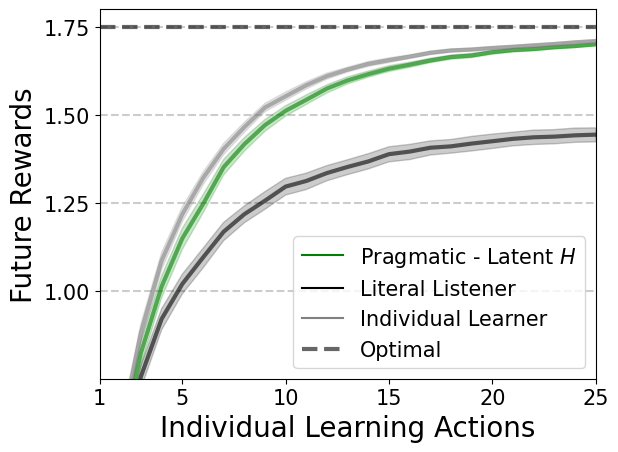

In [28]:
sns.lineplot(data=to_plot, x='trial', y='future_rewards', hue='listener', hue_order=hue_order, palette=palette,
             linewidth=3, alpha=.6)

plt.ylim(.75, 1.8) 
plt.axhline(1.75, c='k', label="Optimal", linestyle='--', linewidth=3, alpha=.6)
plt.legend(loc='best', fontsize=15)

ys = [1, 1.25, 1.5, 1.75]
for y in ys:
    plt.axhline(y, c='k', alpha=.2, linestyle='--', zorder=0)

plt.yticks(ys, fontsize=15)
plt.ylabel("Future Rewards", fontsize=20)
plt.xticks([1, 5, 10, 15, 20, 25], fontsize=15)
plt.xlim(1, 25);
plt.xlabel("Individual Learning Actions", fontsize=20)

# plt.xlim(.5, 15)

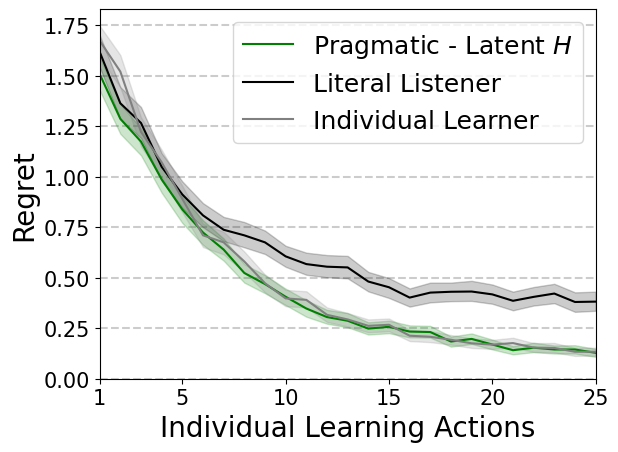

In [29]:
sns.lineplot(data=to_plot, x='trial', y='regret', hue='listener', hue_order=hue_order, palette=palette)

ys=[0, .25, .5, .75, 1, 1.25, 1.5, 1.75]
plt.yticks(ys, fontsize=15)
for y in ys:
    plt.axhline(y, c='k', alpha=.2, linestyle='--', zorder=0)

plt.ylabel("Regret", fontsize=20)
plt.xticks([1, 5, 10, 15, 20, 25], fontsize=15)
plt.xlim(1, 25);
plt.xlabel("Individual Learning Actions", fontsize=20)
plt.legend(fontsize=18)

## Summarize Results

In [30]:
results_to_summarize = results

### Regret @ 25

In [31]:
regret_totals = results_to_summarize.groupby(["listener", "trial_iteration_key"])["regret"].sum().reset_index()

In [32]:
regret_totals.groupby("listener").regret.agg(np.mean).round(2)

listener
individual                           12.45
literal                              16.44
pragmatic_aligned                    12.15
pragmatic_misaligned_conservative    12.14
pragmatic_misaligned_pedagogic       11.90
pragmatic_uncertain                  11.73
Name: regret, dtype: float64

In [33]:
### Export to R
for_r = results_to_summarize.groupby(["listener", "trial_iteration_key", "random_effects_key"]).regret.sum().reset_index()
for_r["centered_regret"] = for_r.regret - for_r.regret.mean()

for_r

,listener,trial_iteration_key,random_effects_key,regret,centered_regret
0,individual,"{'action_context': [{'color': 'blue', 'shape':...","[{'color': 'blue', 'shape': 'spotted'}, {'colo...",10,-2.801667
1,individual,"{'action_context': [{'color': 'blue', 'shape':...","[{'color': 'blue', 'shape': 'spotted'}, {'colo...",12,-0.801667
2,individual,"{'action_context': [{'color': 'blue', 'shape':...","[{'color': 'blue', 'shape': 'spotted'}, {'colo...",19,6.198333
3,individual,"{'action_context': [{'color': 'blue', 'shape':...","[{'color': 'blue', 'shape': 'spotted'}, {'colo...",9,-3.801667
4,individual,"{'action_context': [{'color': 'blue', 'shape':...","[{'color': 'blue', 'shape': 'spotted'}, {'colo...",9,-3.801667
...,...,...,...,...,...
10195,pragmatic_uncertain,"[{'color': 'red', 'shape': 'striped'}, {'color...","[{'color': 'red', 'shape': 'striped'}, {'color...",20,7.198333
10196,pragmatic_uncertain,"[{'color': 'red', 'shape': 'striped'}, {'color...","[{'color': 'red', 'shape': 'striped'}, {'color...",16,3.198333
10197,pragmatic_uncertain,"[{'color': 'red', 'shape': 'striped'}, {'color...","[{'color': 'red', 'shape': 'striped'}, {'color...",22,9.198333
10198,pragmatic_uncertain,"[{'color': 'red', 'shape': 'striped'}, {'color...","[{'color': 'red', 'shape': 'striped'}, {'color...",16,3.198333


In [34]:
#for_r.to_csv("regret_results_for_r.csv", index=False)

# Simulation Details


## Gaussian Prior
How wide should initial variance be?

First, we want this to be large in order to approximate a uniform on the interval [-2, 2]  
However, for importance-sampling we need to sample from it and stay within the (-2.5, 2.5) range.

With variance=5 and 6 dimensions, we should get 66% of samples within (-2.5, 2.5) which means .66^6 ~~ 8% of our initial samples will be accepted.

In [35]:
from scipy.stats import norm
import math

variance = 5

interval = norm.interval(.66, loc=0, scale=math.sqrt(variance))
acceptance = .66**6

print(f'Interval of {interval} --> acceptance of {acceptance}.')

Interval of (-2.1335783678031857, 2.133578367803187) --> acceptance of 0.08265395001600002.
